# ANÁLISE DE DESCONTINUIDADE DE PEDIDOS 

Essa análise tem o objetivo de identificar possíveis motivos para a descontinuidade e atraso de pedidos da empresa Stockwise, com base nos dados extraídos entre fevereiro de 2024 e fevereiro de 2025.

### Possíveis hipóteses iniciais
1. Descontinuado porque o produto específico vende pouco em quantidade em comparação com outros.
2. Descontinuado porque vence rápido demais e tem risco de morrer em estoque antes da venda.
3. Descontinuado porque vende pouco ao ponto de continuar boa quantidade em capital_imobilizado.
4. Risco de descontinuidade porque fornecedor geralmente não entrega aquele produto com muita rapidez.

In [181]:
import pandas as pd

In [182]:
#carrega os dados e transforma para formato de dataset
df=pd.read_csv('stockwise.csv')

In [183]:
df.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,15068 Scoville Court,62,25,Backordered


In [184]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Product_ID               990 non-null    str  
 1   Product_Name             990 non-null    str  
 2   Catagory                 989 non-null    str  
 3   Supplier_ID              990 non-null    str  
 4   Supplier_Name            990 non-null    str  
 5   Stock_Quantity           990 non-null    int64
 6   Reorder_Level            990 non-null    int64
 7   Reorder_Quantity         990 non-null    int64
 8   Unit_Price               990 non-null    str  
 9   Date_Received            990 non-null    str  
 10  Last_Order_Date          990 non-null    str  
 11  Expiration_Date          990 non-null    str  
 12  Warehouse_Location       990 non-null    str  
 13  Sales_Volume             990 non-null    int64
 14  Inventory_Turnover_Rate  990 non-null    int64
 15  Status           

Observações iniciais:
- A coluna "Catagory" mostra ter um valor nulo

## LIMPEZA DE DADOS

In [185]:
df.dtypes

Product_ID                   str
Product_Name                 str
Catagory                     str
Supplier_ID                  str
Supplier_Name                str
Stock_Quantity             int64
Reorder_Level              int64
Reorder_Quantity           int64
Unit_Price                   str
Date_Received                str
Last_Order_Date              str
Expiration_Date              str
Warehouse_Location           str
Sales_Volume               int64
Inventory_Turnover_Rate    int64
Status                       str
dtype: object

Observações iniciais:
- coluna Unit_Price está no formato indevido (str ao invés de float)
- colunas de data (date_received, last_order_date, expiration_date) no estilo str e não datatime

#### Análise e limpeza de variáveis categóricas

In [186]:
df.isnull().sum()

Product_ID                 0
Product_Name               0
Catagory                   1
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Warehouse_Location         0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

In [187]:
#mostra a linha em que se encontra o valor de 'Catagory' nulo
df[df['Catagory'].isna() | (df['Catagory'] == '')]

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
685,10-378-9729,Cabbage,NaN,83-941-9620,Rooxo,69,21,68,$66.55,12/23/2024,11/26/2024,9/21/2024,2 Butterfield Pass,36,35,Discontinued


In [188]:
#preenche o valor nulo de 'Catagory' com a categoria correspondente
df.loc[685, 'Catagory']='Fruits & Vegetables'

In [189]:
#confere se a correção de categoria nula foi feita
df['Catagory'].value_counts()

Catagory
Fruits & Vegetables    332
Dairy                  180
Grains & Pulses        162
Seafood                 90
Oils & Fats             77
Beverages               75
Bakery                  74
Name: count, dtype: int64

In [190]:
#analisa duplicatas
df.duplicated().sum()

np.int64(0)

In [191]:
#analisa valores únicos de nome de fornecedor
df['Supplier_Name'].nunique()

350

In [192]:
#analisa valores únicos de id de fornecedor
df['Supplier_ID'].nunique()

990

In [193]:
#analisa quantas vezes cada fornecedor aparece no dataset
contagem = df['Supplier_Name'].value_counts()
valores_repetidos = contagem[contagem > 1]

print(valores_repetidos)

Supplier_Name
Katz           12
Meevee         10
Quatz           9
Vinder          7
Babblestorm     7
               ..
Topicware       2
Rhybox          2
Yambee          2
Wordware        2
Ooba            2
Name: count, Length: 272, dtype: int64


Importante: supplier_name e supplier_id são inconsistentes entre si. Há 640 (990 registros - 350 valores únicos de fornecedores) ID's diferentes mas que representam nomes que já apareceram mais de uma vez na coluna "Supplier_Name". 

Os pedidos com mesmos fornecedores deveriam ter os mesmos id's. Por isso, serão substituídos todos os Supplier_IDs distintos pelo primeiro ID que apareceu correspondente aquele Supplier_Name.

In [194]:
#corrige os ID's diferentes dentro de um nome específico para o primeiro ID que apareceu
mapa_ids = df.groupby('Supplier_Name')['Supplier_ID'].transform('first')

# substitui a coluna Supplier_ID pela versão corrigida
df['Supplier_ID'] = mapa_ids

In [195]:
#analisa valores únicos de nome de produto
df['Product_Name'].nunique()

121

In [196]:
#analisa valores únicos de id de produto
df['Product_ID'].nunique()

990

In [197]:
contagem = df['Product_Name'].value_counts()
valores_repetidos = contagem[contagem > 1]

print(valores_repetidos)

Product_Name
Bread Flour          19
Arabica Coffee       16
Pomegranate          15
Cauliflower          15
Haddock              14
                     ..
Coconut Oil           4
Whole Wheat Bread     4
Cherry                4
All-Purpose Flour     3
Vanilla Biscuit       3
Name: count, Length: 121, dtype: int64


Observação: diferentemente da inconsistencia do Supplier_Name x Supplier_ID, é super comum ter o mesmo produto de marcas diferentes, por isso, o dado de haver 869 produtos com nomes repetidos mas ID's diferentes é válido. 

### Observações finais:

**Valor nulo**
- Decisão: classificar manualmente dentre as opções de "Catagory"
- Justificativa: após a análise do Supplier_Name do produto com valor nulo, notamos que se tratava de "Cabbage", no qual coube classificar manualmente dentro da categoria "Fruits & Vegetables" que já havia anteriormente.

**Inconsistências**
- Justificativa: Entre a coluna Supplier_Name e Supplier_ID, tomou-se Supplier_Name como base para correção da inconsistência por ter menos valores únicos, consequentemente mais estáveis e menos suscetíveis a erros.
- Resultado: Agora todas as vezes que um Supplier_Name se repetir na tabela, o Supplier_ID dele também se repete. É o mesmo para qualquer produto. (Relação 1:1).

**Duplicatas e inconsistências de texto**
- Como não houveram valores duplicados nem inconsistências, não foi preciso limpeza.

#### Análise e limpeza de variáveis numéricas e de data

In [198]:
#conversão da variável de preço unitário para float
df['Unit_Price'] = df['Unit_Price'].str.strip().str.replace('$', '', regex=False).astype(float)

In [199]:
df['Unit_Price']

0       4.5
1      20.0
2       6.0
3       1.5
4       4.0
       ... 
985     2.5
986     9.0
987     0.9
988    10.0
989     4.5
Name: Unit_Price, Length: 990, dtype: float64

In [200]:
#conversão de tipos: de string para datatime
df['Date_Received']=pd.to_datetime(df['Date_Received'])
df['Last_Order_Date']=pd.to_datetime(df['Last_Order_Date'])
df['Expiration_Date']=pd.to_datetime(df['Expiration_Date'])

In [201]:
df.dtypes

Product_ID                            str
Product_Name                          str
Catagory                              str
Supplier_ID                           str
Supplier_Name                         str
Stock_Quantity                      int64
Reorder_Level                       int64
Reorder_Quantity                    int64
Unit_Price                        float64
Date_Received              datetime64[us]
Last_Order_Date            datetime64[us]
Expiration_Date            datetime64[us]
Warehouse_Location                    str
Sales_Volume                        int64
Inventory_Turnover_Rate             int64
Status                                str
dtype: object

In [202]:
df.isnull().sum()

Product_ID                 0
Product_Name               0
Catagory                   0
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Warehouse_Location         0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

In [203]:
df.describe()

,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate
count,990.000000,990.000000,990.000000,990.000000,990,990,990,990.000000,990.000000
mean,55.609091,51.215152,51.913131,5.924192,2024-08-23 02:18:10.909091,2024-08-25 19:20:43.636363,2024-08-23 06:45:49.090909,58.925253,50.150505
min,10.000000,1.000000,1.000000,0.200000,2024-02-25 00:00:00,2024-02-25 00:00:00,2024-02-25 00:00:00,20.000000,1.000000
25%,33.000000,25.250000,25.000000,2.500000,2024-05-27 00:00:00,2024-05-29 00:00:00,2024-05-23 00:00:00,39.000000,25.000000
50%,56.000000,53.000000,54.000000,4.225000,2024-08-19 00:00:00,2024-08-20 12:00:00,2024-08-23 12:00:00,58.000000,50.000000
75%,79.000000,77.000000,77.000000,7.000000,2024-11-23 00:00:00,2024-11-29 00:00:00,2024-11-23 00:00:00,78.000000,74.750000
max,100.000000,100.000000,100.000000,98.430000,2025-02-24 00:00:00,2025-02-24 00:00:00,2025-02-24 00:00:00,100.000000,100.000000
std,26.300775,29.095241,29.521059,6.491280,NaN,NaN,NaN,23.002318,28.798954


### Observações finais:

**Valores negativos**
- Analisando os valores mínimos de cada coluna numérica, nota-se que não há presença de valores negativos. 

**Ouliers**
- Analisando o std em relação a média e o valor máximo de cada coluna, nota-se que não há presença de outliers gritantes.

## EDA

In [204]:
df['Status'].value_counts()

Status
Discontinued    333
Active          332
Backordered     325
Name: count, dtype: int64

In [205]:
df['Status'].value_counts(normalize=True)

Status
Discontinued    0.336364
Active          0.335354
Backordered     0.328283
Name: proportion, dtype: float64

In [206]:
import matplotlib as mpl

<Axes: xlabel='Status'>

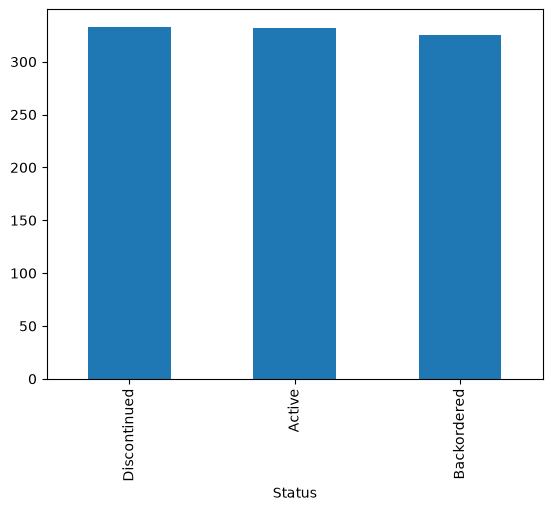

In [207]:
df['Status'].value_counts().plot(kind='bar')

Nota-se uma distribuição extremamente regular entre os registros de produtos descontinuados, ativos e atrasados.

In [208]:
#setando as novas variáveis para análise das hipóteses 2, 3 e 4
df['dias_ate_vencer']=(df['Expiration_Date']-df['Date_Received']).dt.days
df['demora_entrega']=(df['Date_Received']-df['Last_Order_Date']).dt.days
df['capital_imobilizado']=df['Stock_Quantity']*df['Unit_Price']

In [209]:
df.head()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status,dias_ate_vencer,demora_entrega,capital_imobilizado
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,2024-08-16,2024-06-29,2024-09-19,48 Del Sol Trail,32,19,Discontinued,34,48,99.0
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,2024-11-01,2024-05-29,2024-05-08,36 3rd Place,85,1,Discontinued,-177,156,900.0
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,2024-08-03,2024-06-10,2024-09-22,3296 Walton Court,31,34,Backordered,50,54,180.0
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,2024-12-08,2025-02-19,2024-04-17,3 Westerfield Crossing,95,99,Active,-235,-73,18.0
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,2024-07-03,2024-10-11,2024-10-05,15068 Scoville Court,62,25,Backordered,94,-100,148.0


In [210]:
print((df['dias_ate_vencer']<0).sum())
print((df['demora_entrega']<0).sum())

496
514


In [211]:
df[['dias_ate_vencer', 'demora_entrega']].describe()

,dias_ate_vencer,demora_entrega
count,990.000000,990.000000
mean,0.185859,-2.710101
std,150.125993,150.485792
min,-365.000000,-343.000000
25%,-106.750000,-111.000000
50%,-1.500000,-6.000000
75%,100.750000,110.000000
max,344.000000,352.000000


Analisando os campos criados, vê-se que a hipótese 2 (vencimento rápido) e a análise 4 (atraso de entrega) não podem ser sustentadas por eles pois não há uma relação cronológica confiável, com muita presença de valores nulos (cerca de 50% para ambas as variáveis). 

Supõe-se que o erro venha do preenchimento humano incorreto das originais. Date_Received, Last_Order_Date e Expiration_Date não foram atualizadas corretamente.